# 🔍 Analyse Exploratoire — Détection de Fraude Bancaire
**Objectif :** Comprendre la structure des données et identifier les patterns de fraude.

In [1]:
# 📦 Importation des bibliothèques
import pandas as pd          # Pour manipuler les données
import numpy as np           # Pour les calculs mathématiques
import matplotlib.pyplot as plt  # Pour les graphiques
import seaborn as sns        # Pour les graphiques plus jolis

# Configuration de l'affichage
pd.set_option('display.max_columns', None)  # Afficher toutes les colonnes
sns.set_theme(style="whitegrid")            # Style des graphiques
plt.rcParams['figure.figsize'] = (10, 6)   # Taille par défaut des graphiques

print("✅ Bibliothèques importées avec succès !")

✅ Bibliothèques importées avec succès !


In [2]:
# 📂 Chargement du dataset avec le chemin complet
df = pd.read_csv(r'C:\Users\emman\Documents\Portfolio\fraud-detection-ml\data\creditcard.csv')

print(f"✅ Dataset chargé avec succès !")
print(f"📊 Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")

✅ Dataset chargé avec succès !
📊 Dimensions : 284807 lignes x 31 colonnes


In [3]:
# 👀 Afficher les 5 premières lignes du dataset
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# ℹ️ Informations générales sur le dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
# 📊 Statistiques descriptives
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
# 🚨 Distribution des fraudes vs transactions normales
fraudes = df['Class'].value_counts()
pourcentage = df['Class'].value_counts(normalize=True) * 100

print("📊 Nombre de transactions :")
print(f"  ✅ Normales  : {fraudes[0]:,}")
print(f"  🚨 Fraudes   : {fraudes[1]:,}")
print(f"\n📈 Pourcentage de fraudes : {pourcentage[1]:.4f}%")

📊 Nombre de transactions :
  ✅ Normales  : 284,315
  🚨 Fraudes   : 492

📈 Pourcentage de fraudes : 0.1727%


C:\Users\emman\AppData\Local\Temp\ipykernel_7152\3560574816.py:34: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_7152\3560574816.py:35: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.savefig('../reports/01_desequilibre_classes.png', dpi=150, bbox_inches='tight')
C:\Users\emman\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


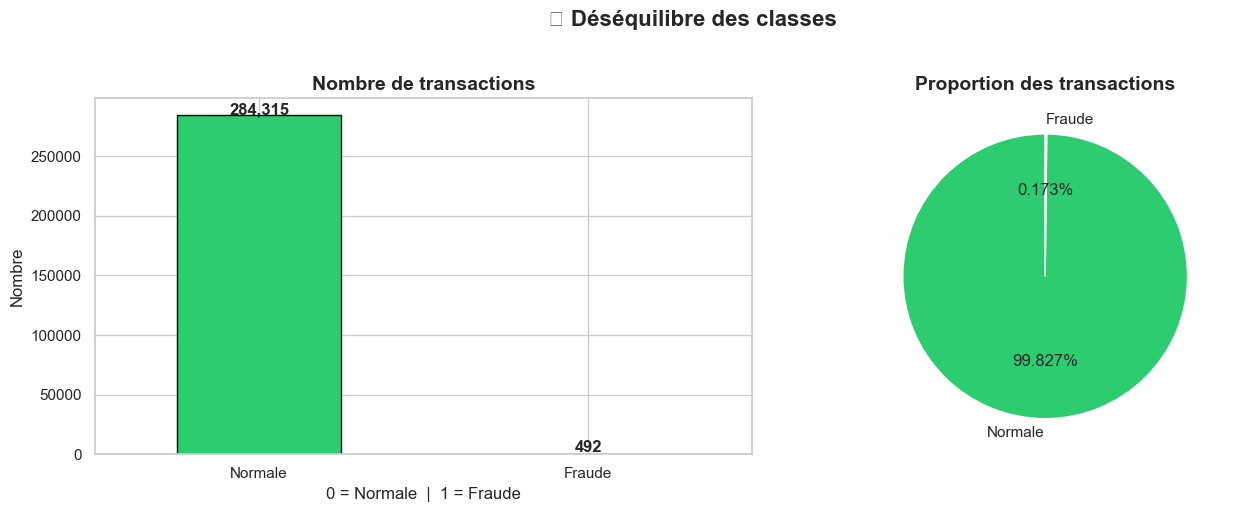

✅ Graphique sauvegardé dans reports/


In [7]:
# 🚨 Visualisation du déséquilibre des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Comptage ---
couleurs = ['#2ecc71', '#e74c3c']
df['Class'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=couleurs,
    edgecolor='black'
)
axes[0].set_title('Nombre de transactions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('0 = Normale  |  1 = Fraude')
axes[0].set_ylabel('Nombre')
axes[0].set_xticklabels(['Normale', 'Fraude'], rotation=0)

# Ajouter les chiffres sur les barres
for i, v in enumerate(df['Class'].value_counts()):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# --- Graphique 2 : Pourcentage ---
df['Class'].value_counts(normalize=True).mul(100).plot(
    kind='pie',
    ax=axes[1],
    colors=couleurs,
    autopct='%1.3f%%',
    startangle=90,
    labels=['Normale', 'Fraude']
)
axes[1].set_title('Proportion des transactions', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('🚨 Déséquilibre des classes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/01_desequilibre_classes.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Graphique sauvegardé dans reports/")

💰 Statistiques des montants :

✅ Transactions NORMALES :
   Moyenne  : 88.29€
   Médiane  : 22.00€
   Maximum  : 25691.16€

🚨 Transactions FRAUDULEUSES :
   Moyenne  : 122.21€
   Médiane  : 9.25€
   Maximum  : 2125.87€


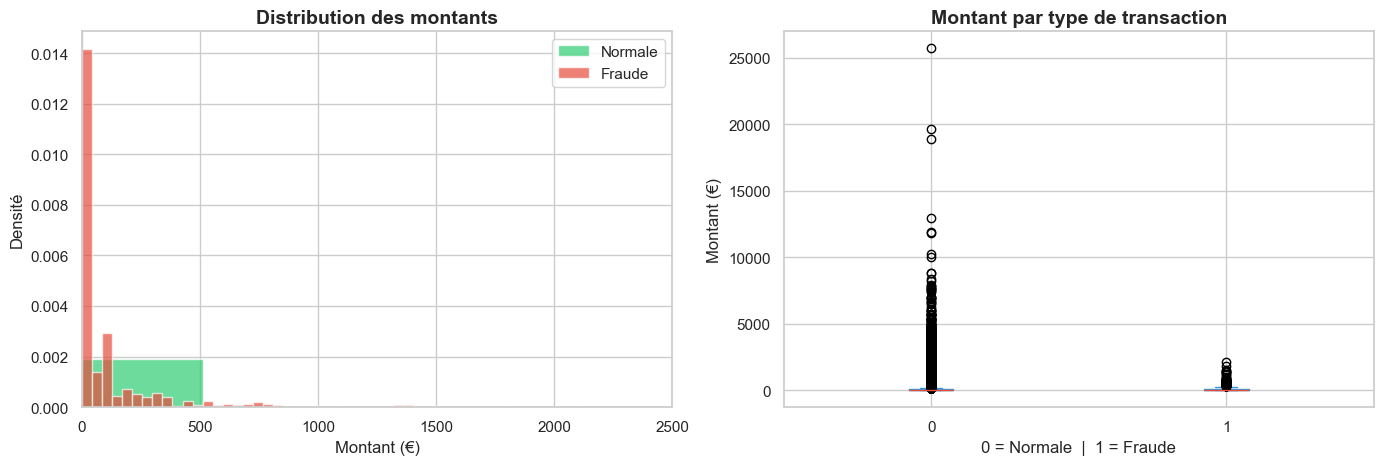

In [8]:
# 💰 Comparaison des montants : Normale vs Fraude
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normale = df[df['Class'] == 0]['Amount']
fraude  = df[df['Class'] == 1]['Amount']

# --- Graphique 1 : Distribution des montants ---
axes[0].hist(normale, bins=50, color='#2ecc71', alpha=0.7, label='Normale', density=True)
axes[0].hist(fraude,  bins=50, color='#e74c3c', alpha=0.7, label='Fraude',  density=True)
axes[0].set_title('Distribution des montants', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Montant (€)')
axes[0].set_ylabel('Densité')
axes[0].legend()
axes[0].set_xlim(0, 2500)

# --- Graphique 2 : Boxplot comparatif ---
df.boxplot(column='Amount', by='Class', ax=axes[1],
           color=dict(boxes='#3498db', whiskers='#3498db',
                      medians='#e74c3c', caps='#3498db'))
axes[1].set_title('Montant par type de transaction', fontsize=14, fontweight='bold')
axes[1].set_xlabel('0 = Normale  |  1 = Fraude')
axes[1].set_ylabel('Montant (€)')
plt.suptitle('')

# --- Statistiques dans le terminal ---
print("💰 Statistiques des montants :")
print(f"\n✅ Transactions NORMALES :")
print(f"   Moyenne  : {normale.mean():.2f}€")
print(f"   Médiane  : {normale.median():.2f}€")
print(f"   Maximum  : {normale.max():.2f}€")
print(f"\n🚨 Transactions FRAUDULEUSES :")
print(f"   Moyenne  : {fraude.mean():.2f}€")
print(f"   Médiane  : {fraude.median():.2f}€")
print(f"   Maximum  : {fraude.max():.2f}€")

plt.tight_layout()
plt.savefig('../reports/02_montants_fraude.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\emman\AppData\Local\Temp\ipykernel_7152\4148453209.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_7152\4148453209.py:31: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_7152\4148453209.py:31: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_7152\4148453209.py:31: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_7152\4148453209.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig('../reports/03_analyse_temporelle.png',
C:\Users\emman\AppData\Local\Temp\ipykernel_7152\4148453209.py:32: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) m

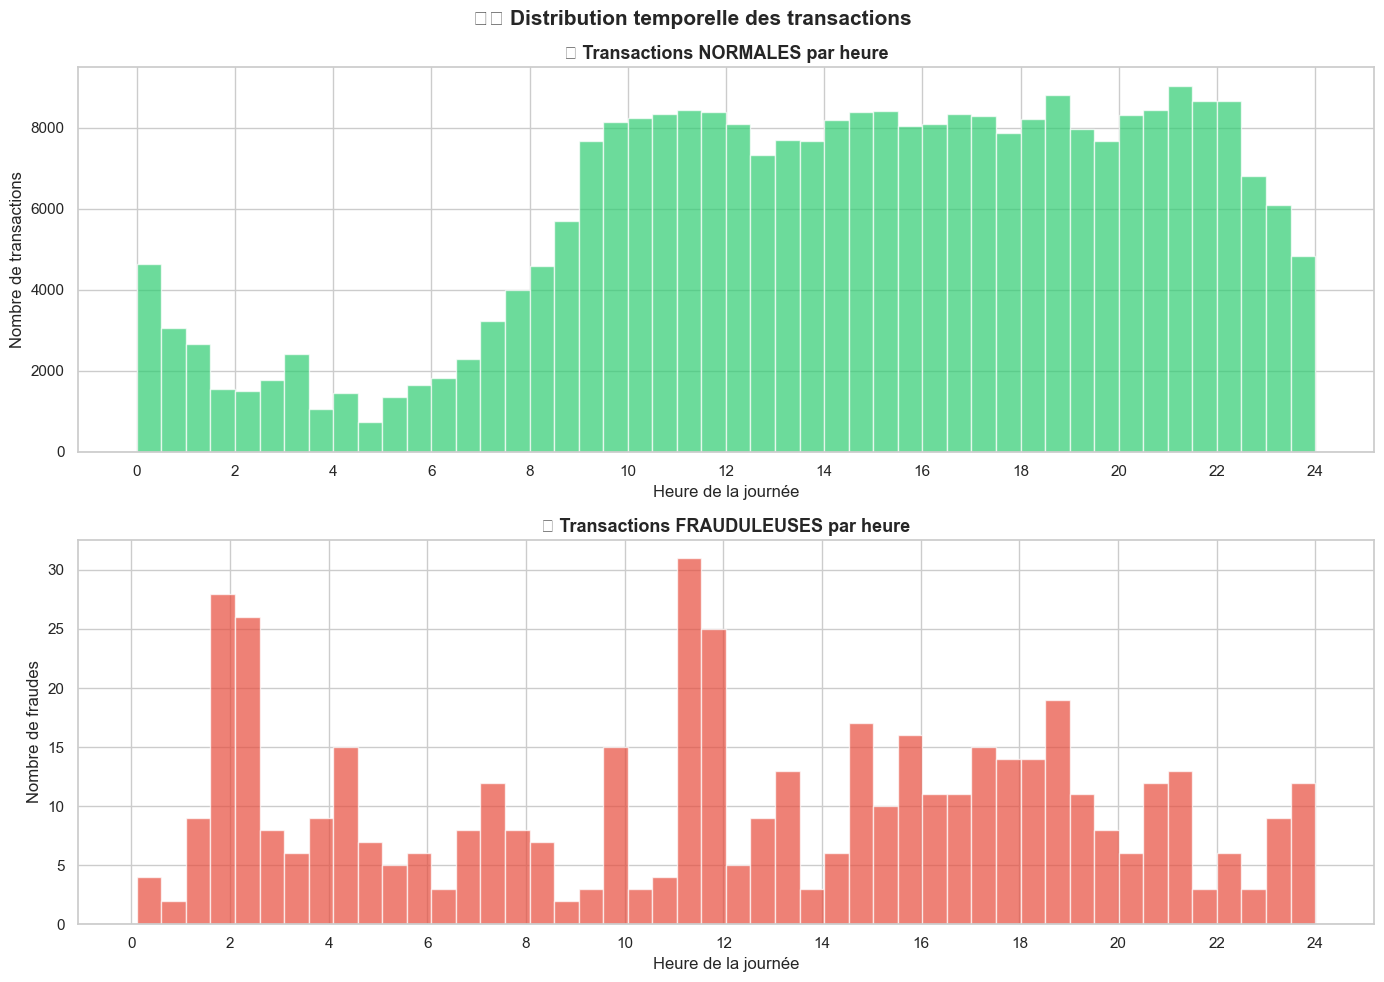

✅ Graphique sauvegardé !


In [9]:
# ⏱️ Analyse temporelle des fraudes
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

normale = df[df['Class'] == 0]
fraude  = df[df['Class'] == 1]

# Convertir les secondes en heures
normale_heures = (normale['Time'] / 3600) % 24
fraude_heures  = (fraude['Time']  / 3600) % 24

# --- Graphique 1 : Transactions normales par heure ---
axes[0].hist(normale_heures, bins=48, color='#2ecc71',
             alpha=0.7, edgecolor='white')
axes[0].set_title('✅ Transactions NORMALES par heure',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Nombre de transactions')
axes[0].set_xticks(range(0, 25, 2))

# --- Graphique 2 : Fraudes par heure ---
axes[1].hist(fraude_heures, bins=48, color='#e74c3c',
             alpha=0.7, edgecolor='white')
axes[1].set_title('🚨 Transactions FRAUDULEUSES par heure',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Heure de la journée')
axes[1].set_ylabel('Nombre de fraudes')
axes[1].set_xticks(range(0, 25, 2))

plt.suptitle('⏱️ Distribution temporelle des transactions',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_analyse_temporelle.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Graphique sauvegardé !")